# ResizeConv -> ConvTranspose Parameter Space Explorer

This notebook builds a large ResizeConv configuration space and computes the ConvTranspose configuration generated by the Resize+Conv to ConvTranspose conversion rules.

It models the transformation logic from:
- build/finn/deps/qonnx/src/qonnx/transformation/resize_conv_to_deconv.py

## Notes

- This notebook focuses on parameter-space mapping, not ONNX graph rewriting.
- It enforces the supported subset used by the transformation:
  - nearest resize
  - NCHW 2D
  - group = 1
  - dilation = (1, 1)
  - square spatial scale

In [1]:
from dataclasses import dataclass, asdict
from itertools import product
from typing import Dict, List, Tuple

try:
    import pandas as pd
except Exception:
    pd = None

In [2]:
@dataclass
class ResizeConvConfig:
    name: str
    in_ch: int
    out_ch: int
    kernel_hw: Tuple[int, int]
    resize_scale: int
    conv_stride_hw: Tuple[int, int] = (1, 1)
    conv_pads_tlbr: Tuple[int, int, int, int] = (0, 0, 0, 0)
    group: int = 1
    dilation_hw: Tuple[int, int] = (1, 1)
    resize_mode: str = "nearest"


def validate_supported(cfg: ResizeConvConfig) -> Tuple[bool, str]:
    if cfg.resize_mode != "nearest":
        return False, "resize_mode must be nearest"
    if cfg.group != 1:
        return False, "group must be 1"
    if cfg.dilation_hw != (1, 1):
        return False, "dilation must be (1,1)"
    if cfg.resize_scale < 1:
        return False, "resize_scale must be >= 1"
    kh, kw = cfg.kernel_hw
    if kh < 1 or kw < 1:
        return False, "kernel dimensions must be >= 1"
    return True, "ok"


def map_resizeconv_to_tconv(cfg: ResizeConvConfig) -> Dict:
    ok, reason = validate_supported(cfg)
    if not ok:
        return {
            "name": cfg.name,
            "supported": False,
            "reason": reason,
        }

    kh, kw = cfg.kernel_hw
    s = cfg.resize_scale

    tconv_kernel = (kh + s - 1, kw + s - 1)
    tconv_stride = (s, s)
    tconv_pads = cfg.conv_pads_tlbr

    conv_params_per_pair = kh * kw
    tconv_entries_per_pair = tconv_kernel[0] * tconv_kernel[1]
    reachable_dof_upper_bound = conv_params_per_pair

    return {
        "name": cfg.name,
        "supported": True,
        "in_ch": cfg.in_ch,
        "out_ch": cfg.out_ch,
        "kernel_hw_conv": cfg.kernel_hw,
        "resize_scale": s,
        "stride_hw_conv": cfg.conv_stride_hw,
        "pads_tlbr_conv": cfg.conv_pads_tlbr,
        "kernel_hw_tconv": tconv_kernel,
        "stride_hw_tconv": tconv_stride,
        "pads_tlbr_tconv": tconv_pads,
        "group_tconv": 1,
        "dilation_hw_tconv": (1, 1),
        "conv_params_per_channel_pair": conv_params_per_pair,
        "tconv_entries_per_channel_pair": tconv_entries_per_pair,
        "reachable_dof_upper_bound": reachable_dof_upper_bound,
    }

In [3]:
# Build a large valid ResizeConv configuration space
kernel_choices = [(1, 1), (3, 3), (5, 5)]
scale_choices = [2, 3, 4]
channel_choices = [(8, 8), (8, 16), (16, 16)]

# Same-padding convention for odd kernels
def same_pad_tlbr(kernel_hw: Tuple[int, int]) -> Tuple[int, int, int, int]:
    kh, kw = kernel_hw
    return (kh // 2, kw // 2, kh // 2, kw // 2)

configs: List[ResizeConvConfig] = []
for idx, (k, s, ch) in enumerate(product(kernel_choices, scale_choices, channel_choices), start=1):
    in_ch, out_ch = ch
    cfg = ResizeConvConfig(
        name=f"cfg_{idx:03d}",
        in_ch=in_ch,
        out_ch=out_ch,
        kernel_hw=k,
        resize_scale=s,
        conv_stride_hw=(1, 1),
        conv_pads_tlbr=same_pad_tlbr(k),
    )
    configs.append(cfg)

len(configs)

27

In [4]:
# Run mapping for all configs
results = [map_resizeconv_to_tconv(cfg) for cfg in configs]

supported = [r for r in results if r["supported"]]
unsupported = [r for r in results if not r["supported"]]

print(f"Total configs: {len(results)}")
print(f"Supported: {len(supported)}")
print(f"Unsupported: {len(unsupported)}")

Total configs: 27
Supported: 27
Unsupported: 0


In [5]:
# Show the first 12 mapped configs
preview = supported[:12]

if pd is not None:
    df_preview = pd.DataFrame(preview)
    display(df_preview)
else:
    for row in preview:
        print(row)

,name,supported,in_ch,out_ch,kernel_hw_conv,resize_scale,stride_hw_conv,pads_tlbr_conv,kernel_hw_tconv,stride_hw_tconv,pads_tlbr_tconv,group_tconv,dilation_hw_tconv,conv_params_per_channel_pair,tconv_entries_per_channel_pair,reachable_dof_upper_bound
0,cfg_001,True,8,8,"(1, 1)",2,"(1, 1)","(0, 0, 0, 0)","(2, 2)","(2, 2)","(0, 0, 0, 0)",1,"(1, 1)",1,4,1
1,cfg_002,True,8,16,"(1, 1)",2,"(1, 1)","(0, 0, 0, 0)","(2, 2)","(2, 2)","(0, 0, 0, 0)",1,"(1, 1)",1,4,1
2,cfg_003,True,16,16,"(1, 1)",2,"(1, 1)","(0, 0, 0, 0)","(2, 2)","(2, 2)","(0, 0, 0, 0)",1,"(1, 1)",1,4,1
3,cfg_004,True,8,8,"(1, 1)",3,"(1, 1)","(0, 0, 0, 0)","(3, 3)","(3, 3)","(0, 0, 0, 0)",1,"(1, 1)",1,9,1
4,cfg_005,True,8,16,"(1, 1)",3,"(1, 1)","(0, 0, 0, 0)","(3, 3)","(3, 3)","(0, 0, 0, 0)",1,"(1, 1)",1,9,1
5,cfg_006,True,16,16,"(1, 1)",3,"(1, 1)","(0, 0, 0, 0)","(3, 3)","(3, 3)","(0, 0, 0, 0)",1,"(1, 1)",1,9,1
6,cfg_007,True,8,8,"(1, 1)",4,"(1, 1)","(0, 0, 0, 0)","(4, 4)","(4, 4)","(0, 0, 0, 0)",1,"(1, 1)",1,16,1
7,cfg_008,True,8,16,"(1, 1)",4,"(1, 1)","(0, 0, 0, 0)","(4, 4)","(4, 4)","(0, 0, 0, 0)",1,"(1, 1)",1,16,1
8,cfg_009,True,16,16,"(1, 1)",4,"(1, 1)","(0, 0, 0, 0)","(4, 4)","(4, 4)","(0, 0, 0, 0)",1,"(1, 1)",1,16,1
9,cfg_010,True,8,8,"(3, 3)",2,"(1, 1)","(1, 1, 1, 1)","(4, 4)","(2, 2)","(1, 1, 1, 1)",1,"(1, 1)",9,16,9


In [6]:
# Create exactly four hand-picked configurations and their generated TCONV parameters
four_cfgs = [
    ResizeConvConfig(name="C1", in_ch=8, out_ch=16, kernel_hw=(3, 3), resize_scale=2, conv_pads_tlbr=(1, 1, 1, 1)),
    ResizeConvConfig(name="C2", in_ch=8, out_ch=16, kernel_hw=(5, 5), resize_scale=2, conv_pads_tlbr=(2, 2, 2, 2)),
    ResizeConvConfig(name="C3", in_ch=16, out_ch=16, kernel_hw=(3, 3), resize_scale=3, conv_pads_tlbr=(1, 1, 1, 1)),
    ResizeConvConfig(name="C4", in_ch=16, out_ch=8, kernel_hw=(1, 1), resize_scale=4, conv_pads_tlbr=(0, 0, 0, 0)),
]

four_results = [map_resizeconv_to_tconv(cfg) for cfg in four_cfgs]

if pd is not None:
    df_four = pd.DataFrame(four_results)
    display(df_four)
else:
    for row in four_results:
        print(row)

,name,supported,in_ch,out_ch,kernel_hw_conv,resize_scale,stride_hw_conv,pads_tlbr_conv,kernel_hw_tconv,stride_hw_tconv,pads_tlbr_tconv,group_tconv,dilation_hw_tconv,conv_params_per_channel_pair,tconv_entries_per_channel_pair,reachable_dof_upper_bound
0,C1,True,8,16,"(3, 3)",2,"(1, 1)","(1, 1, 1, 1)","(4, 4)","(2, 2)","(1, 1, 1, 1)",1,"(1, 1)",9,16,9
1,C2,True,8,16,"(5, 5)",2,"(1, 1)","(2, 2, 2, 2)","(6, 6)","(2, 2)","(2, 2, 2, 2)",1,"(1, 1)",25,36,25
2,C3,True,16,16,"(3, 3)",3,"(1, 1)","(1, 1, 1, 1)","(5, 5)","(3, 3)","(1, 1, 1, 1)",1,"(1, 1)",9,25,9
3,C4,True,16,8,"(1, 1)",4,"(1, 1)","(0, 0, 0, 0)","(4, 4)","(4, 4)","(0, 0, 0, 0)",1,"(1, 1)",1,16,1


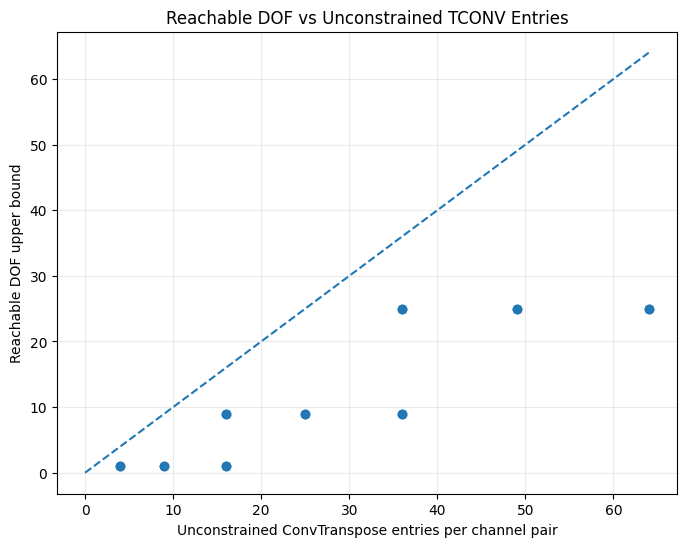

,kernel_hw_conv,resize_scale,count,avg_tconv_entries,avg_reachable_dof
0,"(1, 1)",2,3,4.0,1.0
1,"(1, 1)",3,3,9.0,1.0
2,"(1, 1)",4,3,16.0,1.0
3,"(3, 3)",2,3,16.0,9.0
4,"(3, 3)",3,3,25.0,9.0
5,"(3, 3)",4,3,36.0,9.0
6,"(5, 5)",2,3,36.0,25.0
7,"(5, 5)",3,3,49.0,25.0
8,"(5, 5)",4,3,64.0,25.0


In [7]:
# Visualization: reachable DOF vs unconstrained ConvTranspose entries
# Uses the full sweep results from the earlier cells.

if pd is None:
    print("pandas not available; skipping visualization.")
else:
    try:
        import matplotlib.pyplot as plt

        df_all = pd.DataFrame(supported)
        x = df_all["tconv_entries_per_channel_pair"]
        y = df_all["reachable_dof_upper_bound"]

        plt.figure(figsize=(8, 6))
        plt.scatter(x, y, alpha=0.75)

        # Identity line for reference: points below this are strict subset cases.
        lim = int(max(x.max(), y.max()))
        plt.plot([0, lim], [0, lim], linestyle="--")

        plt.title("Reachable DOF vs Unconstrained TCONV Entries")
        plt.xlabel("Unconstrained ConvTranspose entries per channel pair")
        plt.ylabel("Reachable DOF upper bound")
        plt.grid(True, alpha=0.25)
        plt.show()

        # Optional grouped summary by kernel and scale
        summary = (
            df_all.groupby(["kernel_hw_conv", "resize_scale"], as_index=False)
            .agg(
                count=("name", "count"),
                avg_tconv_entries=("tconv_entries_per_channel_pair", "mean"),
                avg_reachable_dof=("reachable_dof_upper_bound", "mean"),
            )
            .sort_values(["kernel_hw_conv", "resize_scale"])
        )
        display(summary)
    except Exception as e:
        print(f"Visualization skipped due to: {e}")

In [8]:
# Optional export for downstream analysis
import json
from pathlib import Path

out_dir = Path(".")
json_path = out_dir / "resizeconv_to_tconv_mapped_space.json"
json_path.write_text(json.dumps(results, indent=2))
print(f"Wrote: {json_path}")

if pd is not None:
    csv_path = out_dir / "resizeconv_to_tconv_mapped_space.csv"
    pd.DataFrame(results).to_csv(csv_path, index=False)
    print(f"Wrote: {csv_path}")

Wrote: resizeconv_to_tconv_mapped_space.json
Wrote: resizeconv_to_tconv_mapped_space.csv
